In [1]:
!pip install -q tensorflow tensorflow-probability imageio kaggle

from google.colab import files

In [2]:
import glob
import time
import numpy as np
import matplotlib.pyplot as plt
import PIL
import imageio.v2 as imageio

import tensorflow as tf
import tensorflow_probability as tfp
from IPython import display

In [5]:
import kagglehub

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Dataset path:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset path: /kaggle/input/gtsrb-german-traffic-sign


In [ ]:

import os
import random

DATA_DIR = "/kaggle/input/gtsrb-german-traffic-sign/Train"

# Select limited classes
SELECTED_CLASSES = ['1', '2', '3', '4', '5']

image_paths = []

for cls in SELECTED_CLASSES:
    class_dir = os.path.join(DATA_DIR, cls)
    if os.path.exists(class_dir):
        files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.endswith(".png")
        ]
        image_paths.extend(files)

random.shuffle(image_paths)
image_paths = image_paths[:6000]

print("Total images used:", len(image_paths))

Class 1: 2220 images
Class 2: 2250 images
Class 3: 1410 images
Class 4: 1980 images
Class 5: 1860 images
Total images used: 6000


In [8]:
IMG_SIZE = 28
BATCH_SIZE = 32

def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.image.rgb_to_grayscale(image)
    image = tf.cast(image, tf.float32) / 255.0
    return image

all_ds = tf.data.Dataset.from_tensor_slices(image_paths)
all_ds = all_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

dataset_size = len(image_paths)
train_size = int(0.8 * dataset_size)

train_dataset = (
    all_ds.take(train_size)
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    all_ds.skip(train_size)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Train:", train_size)
print("Test:", dataset_size - train_size)

Train: 4800
Test: 1200


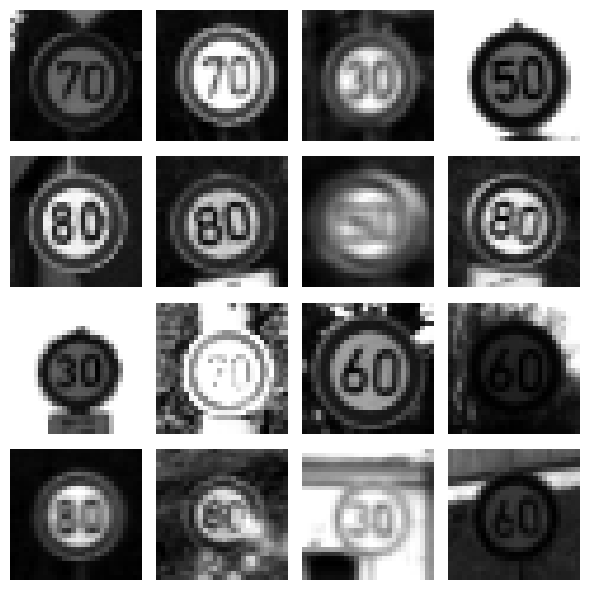

In [9]:
plt.figure(figsize=(6, 6))

for batch in train_dataset.take(1):
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(batch[i, :, :, 0], cmap="gray")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
LATENT_DIM = 8
EPOCHS = 25

class CVAE(tf.keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(shape=(28, 28, 1)),
            tf.keras.layers.Conv2D(32, 3, strides=2, activation="relu"),
            tf.keras.layers.Conv2D(64, 3, strides=2, activation="relu"),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ])

        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(shape=(latent_dim,)),
            tf.keras.layers.Dense(7 * 7 * 32, activation="relu"),
            tf.keras.layers.Reshape((7, 7, 32)),
            tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu"),
            tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu"),
            tf.keras.layers.Conv2DTranspose(1, 3, strides=1, padding="same"),
        ])

    def encode(self, x):
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=tf.shape(mean))
        return eps * tf.exp(0.5 * logvar) + mean

    def decode(self, z, apply_sigmoid=False):
        logits = self.decoder(z)
        if apply_sigmoid:
            return tf.sigmoid(logits)
        return logits

    @tf.function
    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(16, self.latent_dim))
        return self.decode(eps, apply_sigmoid=True)

model = CVAE(LATENT_DIM)
optimizer = tf.keras.optimizers.Adam(1e-4)

In [11]:
def log_normal_pdf(sample, mean, logvar, axis=1):
    log2pi = tf.math.log(2.0 * np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample - mean) ** 2 * tf.exp(-logvar) + logvar + log2pi),
        axis=axis
    )

def compute_loss(model, x):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z)

    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
    logpz = log_normal_pdf(z, 0.0, 0.0)
    logqz_x = log_normal_pdf(z, mean, logvar)

    return -tf.reduce_mean(logpx_z + logpz - logqz_x)

@tf.function
def train_step(model, x):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, x)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

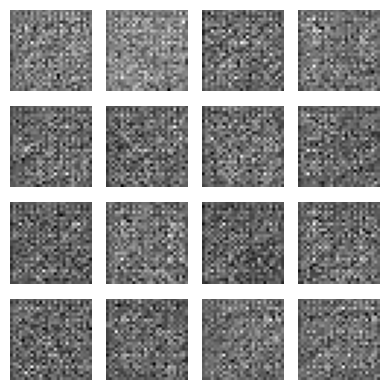

In [12]:
for test_batch in test_dataset.take(1):
    test_sample = test_batch[:16]

def generate_and_save_images(model, epoch, test_sample):
    mean, logvar = model.encode(test_sample)
    z = model.reparameterize(mean, logvar)
    predictions = model.decode(z, apply_sigmoid=True)

    plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"image_at_epoch_{epoch:03d}.png")
    plt.show()

generate_and_save_images(model, 0, test_sample)

Epoch 25, Test ELBO: -394.2539, Time: 2.09s


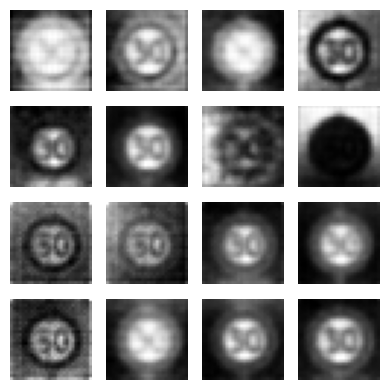

In [13]:
for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    for train_x in train_dataset:
        train_step(model, train_x)

    end_time = time.time()

    loss_metric = tf.keras.metrics.Mean()
    for test_x in test_dataset:
        loss_metric(compute_loss(model, test_x))

    elbo = -loss_metric.result()
    display.clear_output(wait=True)
    print(f"Epoch {epoch}, Test ELBO: {elbo:.4f}, Time: {end_time - start_time:.2f}s")
    generate_and_save_images(model, epoch, test_sample)

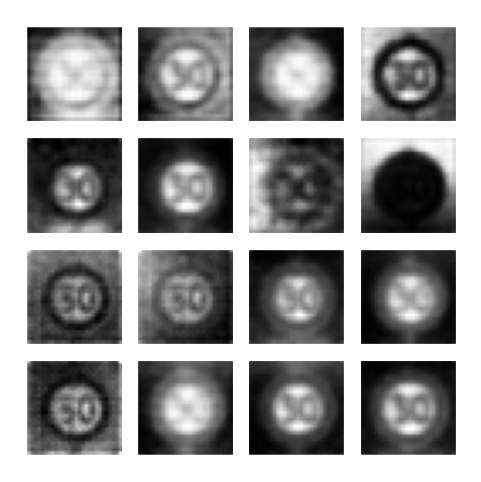

Saved GIF: cvae_gtsrb.gif


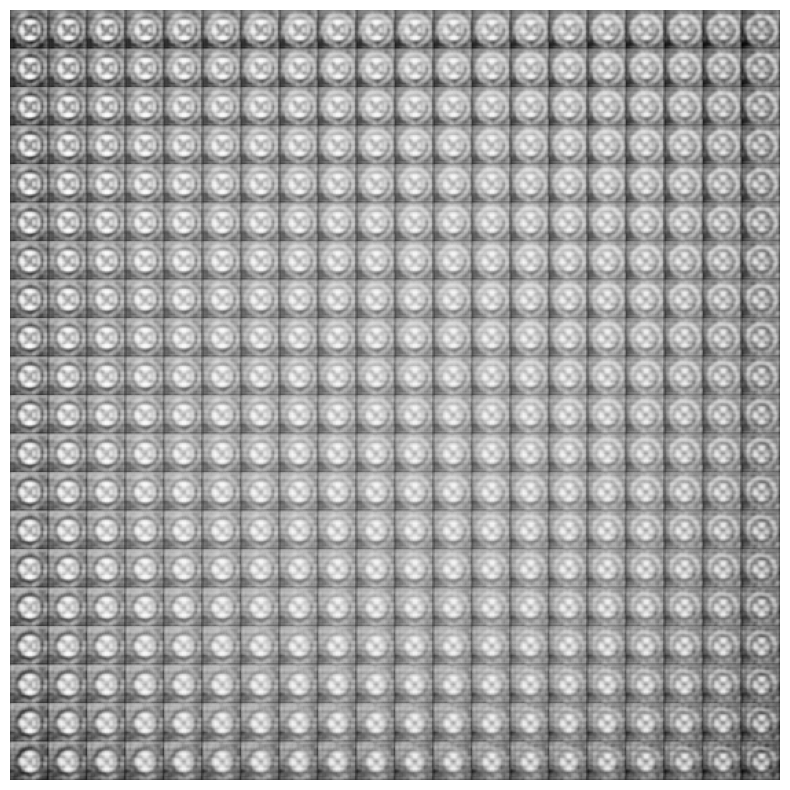

In [14]:
plt.figure(figsize=(6, 6))
plt.imshow(PIL.Image.open(f"image_at_epoch_{EPOCHS:03d}.png"))
plt.axis("off")
plt.show()

anim_file = "cvae_gtsrb.gif"
with imageio.get_writer(anim_file, mode="I") as writer:
    filenames = sorted(glob.glob("image_at_epoch_*.png"))
    for filename in filenames:
        writer.append_data(imageio.imread(filename))
    writer.append_data(imageio.imread(filenames[-1]))

print("Saved GIF:", anim_file)
def plot_latent_images(model, n=20, image_size=28):
    norm = tfp.distributions.Normal(0, 1)
    grid_x = norm.quantile(np.linspace(0.05, 0.95, n))
    grid_y = norm.quantile(np.linspace(0.05, 0.95, n))

    image = np.zeros((image_size * n, image_size * n))

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z = np.zeros((1, LATENT_DIM), dtype=np.float32)
            z[0, 0] = xi
            z[0, 1] = yi

            x_decoded = model.decode(z, apply_sigmoid=True)
            img = tf.reshape(x_decoded[0], (image_size, image_size))

            image[
                i * image_size:(i + 1) * image_size,
                j * image_size:(j + 1) * image_size
            ] = img.numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.show()

plot_latent_images(model, 20)